# Automated Sea Snake Contraction, Spline Generation, Straightening & Armature Rigging

This notebook demonstrates the end-to-end procedural animation pipeline:
1. **Contraction Skeleton Points**: Extract 1D skeleton points via mesh contraction & Algo B slice centroiding.
2. **Catmull-Rom Spline Generation**: Convert ordered skeleton points into a Catmull-Rom `Spline` object.
3. **Spine & Mesh Straightening**: Straighten the spline curve & 3D mesh using Bishop parallel transport frames.
4. **Straightened Armature Construction**: Build hierarchical `Armature` bones along the straightened spine.

In [7]:
import os
import sys
import time
import numpy as np
import torch
import trimesh
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

import bpy 
import numpy as np

sys.path.append("..")

from animgen.core.spline import Spline
from animgen.core.armature import Armature, Bone
from animgen.rigging.mesh_contraction import extract_skeleton
from animgen.rigging.refine_skelaton import refine_and_center_skeleton_iterative
from animgen.animation.straight import straighten, deform_mesh_to_spine_numpy

from animgen.io.glb_output import export_glb

print("Libraries successfully imported!")

Libraries successfully imported!


## 1. Load Sea Snake 3D Mesh

In [8]:
# 1. Load snake mesh
mesh_path = "../generated_data/test/dec_mesh_Sea_Snake.glb"
if not os.path.exists(mesh_path):
    mesh_path = "generated_data/test/dec_mesh_Sea_Snake.glb"
if not os.path.exists(mesh_path):
    mesh_path = "../generated_data/models/models_backup_3/dec_mesh_Sea_Snake.glb"
if not os.path.exists(mesh_path):
    mesh_path = "generated_data/models/models_backup_3/dec_mesh_Sea_Snake.glb"

scene = trimesh.load(mesh_path)
mesh = scene.to_mesh() if isinstance(scene, trimesh.Scene) else scene
print(f"Mesh loaded: {len(mesh.vertices)} vertices, {len(mesh.faces)} faces")

Loaded Mesh: ../generated_data/test/dec_mesh_Sea_Snake.glb
Surface Vertices: 6431, Faces: 12862


## 2. Extract Skeleton Contraction Points & Algo B Refinement

In [9]:
t0 = time.time()
skel_v, skel_e = extract_skeleton(
    mesh, max_iters=20, threshold=0.5, no_1d_collapses=True, return_tuple=True
)
t_ext = time.time() - t0
print(f"[1] Contraction Skeleton Extracted in {t_ext:.2f}s: {len(skel_v)} nodes, {len(skel_e)} edges")

# High-Density Algo B Iterative Slice Centering (max_edge_len=0.1)
skel_v_final, skel_e_ref = refine_and_center_skeleton_iterative(mesh.vertices, skel_v, skel_e, max_edge_len=0.1, num_iters=10)
print(f"[2] High-Density Algo B Refined Skeleton: {len(skel_v_final)} nodes, {len(skel_e_ref)} edges")

[1] Contraction Skeleton Extracted in 6.52s: 18 nodes, 17 edges
[2] High-Density Algo B Refined Skeleton: 66 nodes, 65 edges


## 3. Convert Skeleton Points to Catmull-Rom Spline

In [10]:
# Trace ordered 1D spine chain
adj = {i: [] for i in range(len(skel_v_final))}
for u, v in skel_e_ref:
    adj[u].append(v)
    adj[v].append(u)

endpoints = [i for i, nbs in adj.items() if len(nbs) == 1]
start_node = endpoints[0] if len(endpoints) > 0 else 0

chain = [start_node]
visited = {start_node}
curr = start_node
while True:
    next_nodes = [nb for nb in adj[curr] if nb not in visited]
    if not next_nodes:
        break
    next_node = next_nodes[0]
    visited.add(next_node)
    chain.append(next_node)
    curr = next_node

ordered_verts = skel_v_final[chain]

# Convert points to Catmull-Rom Spline
pts_t_all = [torch.tensor(v, dtype=torch.float32) for v in ordered_verts]
spline = Spline(pts_t_all, alpha=1, phantom_num_points=1)
eval_pts_t = spline.evaluate_curve(num_points_per_segment=5)
source_spine = np.array([pt.detach().cpu().numpy() for pt in eval_pts_t])

print(f"../generated Catmull-Rom Spline Object from {len(ordered_verts)} control points ({len(source_spine)} evaluated curve points)")

../generated Catmull-Rom Spline Object from 64 control points (253 evaluated curve points)


## 4. Straighten Spline & Deform Mesh

In [11]:
# Straighten mesh using Spline curve
t0 = time.time()
straight_mesh = straighten(mesh, spine_points=spline, axis="x")
t_def = time.time() - t0
print(f"Straightened mesh along Spline in {t_def:.2f}s!")

# Compute target straight spine points matching cumulative arc length
seg_lens = np.linalg.norm(np.diff(source_spine, axis=0), axis=1)
s = np.concatenate(([0.0], np.cumsum(seg_lens)))
total_len = s[-1]

target_spine = np.zeros_like(source_spine)
target_spine[:, 0] = s
print(f"Straightened Spine Total Arc Length: {total_len:.4f} units")

Straightened mesh along Spline in 0.24s!
Straightened Spine Total Arc Length: 3.8295 units


## 5. Construct Hierarchical Armature on Straightened Spine & Export GLB

Constructed Straightened Armature with 19 connected bones!
Successfully exported rigged straightened GLB asset to: ../generated_data/rigged/straightened_dec_mesh_Sea_Snake.glb


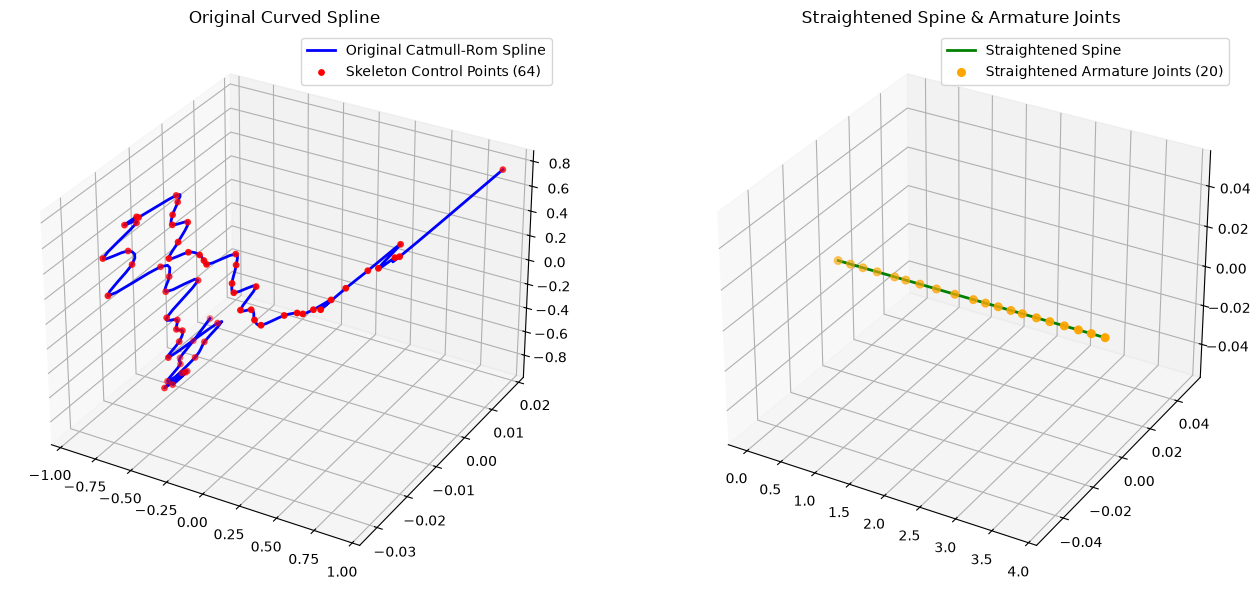

In [12]:
# Select 20 equidistant node points along straightened spine for bones
armature_node_indices = np.linspace(0, len(target_spine) - 1, 20, dtype=int)
straight_armature_verts = target_spine[armature_node_indices]

# Construct Armature
root_bone = Bone(
    head=tuple(straight_armature_verts[0]),
    tail=tuple(straight_armature_verts[1]),
)
straight_armature = Armature(root_bone)
curr_bone = root_bone
for i in range(2, len(straight_armature_verts)):
    curr_bone = straight_armature.add_connected_bone(
        curr_bone, tail=tuple(straight_armature_verts[i])
    )

print(f"Constructed Straightened Armature with {len(straight_armature.bones_list)} connected bones!")

out_dir = "../generated_data/rigged" if os.path.exists("../generated_data") else "generated_data/rigged"
os.makedirs(out_dir, exist_ok=True)
out_path_straight = os.path.join(out_dir, "straightened_dec_mesh_Sea_Snake.glb")
export_glb(straight_mesh, out_path_straight, armature=straight_armature)
print(f"Exported rigged & straightened snake mesh to: {out_path_straight}")